In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow import keras
from tensorflow.keras import layers

DATA_DIR   = '/Users/giannalongo/Downloads/pioneer/476_Final'
OUTPUT_DIR = '/Users/giannalongo/Downloads/pioneer/476_Final'


# LOAD DATA

def load_data(data_dir):
    waveforms = np.load(os.path.join(data_dir, 'dataset_waveforms.npy'))
    labels    = np.load(os.path.join(data_dir, 'dataset_labels.npy'))
    return waveforms, labels


# PREPROCESSING


def preprocess(waveforms, labels, downsample=10):
    X = waveforms[:, ::downsample].astype(np.float32)
    X = X / 16383.0
    X = X.reshape(X.shape[0], X.shape[1], 1)
    Y = keras.utils.to_categorical(labels, num_classes=3)
    return X, Y


# REDUCED MODEL


def build_small_model(input_length=200):
    """
    Smaller CNN for FPGA deployment.
    Reduced filters and dense units compared to original model.
    Target: under 500 DSPs on Artix-7.
    """
    model = keras.Sequential([

        # Conv block 1 - reduced from 8 to 4 filters
        layers.Conv1D(4, kernel_size=5, activation='relu',
                      input_shape=(input_length, 1), padding='same'),
        layers.MaxPooling1D(pool_size=2),

        # Conv block 2 - reduced from 16 to 8 filters
        layers.Conv1D(8, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),

        # Conv block 3 - reduced from 16 to 8 filters
        layers.Conv1D(8, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),

        # Dense - reduced from 32 to 16 neurons
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# PLOTTING


def plot_training(history, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'],  label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'],  label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'training_history_small.png'), dpi=150)
    plt.show()

X shape: (5000, 200, 1)
Y shape: (5000, 3)
Train: 3500  Val: 750  Test: 750
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 200, 4)            24        
                                                                 
 max_pooling1d (MaxPooling1D  (None, 100, 4)           0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 100, 8)            168       
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 50, 8)            0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 50, 8)             200       
                                              

2026-05-07 13:23:30.927940: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


55/55 [==============================] - 1s 4ms/step - loss: 1.0988 - accuracy: 0.3386 - val_loss: 1.0984 - val_accuracy: 0.3387
Epoch 2/60
55/55 [==============================] - 0s 3ms/step - loss: 1.0988 - accuracy: 0.3377 - val_loss: 1.0984 - val_accuracy: 0.3387
Epoch 3/60
55/55 [==============================] - 0s 3ms/step - loss: 1.0984 - accuracy: 0.3360 - val_loss: 1.0982 - val_accuracy: 0.3387
Epoch 4/60
55/55 [==============================] - 0s 3ms/step - loss: 1.0984 - accuracy: 0.3320 - val_loss: 1.0982 - val_accuracy: 0.3360
Epoch 5/60
55/55 [==============================] - 0s 3ms/step - loss: 1.0982 - accuracy: 0.3437 - val_loss: 1.0978 - val_accuracy: 0.3387
Epoch 6/60
55/55 [==============================] - 0s 3ms/step - loss: 1.0983 - accuracy: 0.3411 - val_loss: 1.0980 - val_accuracy: 0.3360
Epoch 7/60
55/55 [==============================] - 0s 3ms/step - loss: 1.0979 - accuracy: 0.3423 - val_loss: 1.0975 - val_accuracy: 0.3387
Epoch 8/60
55/55 [=============

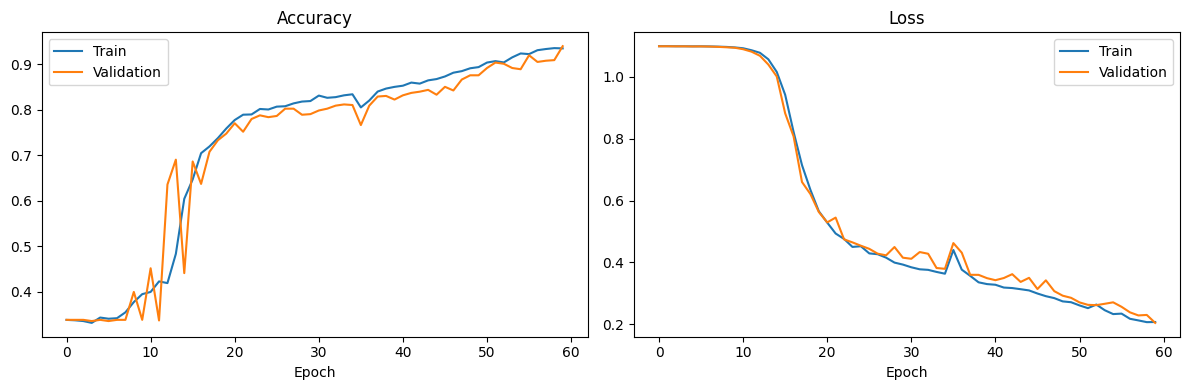

In [2]:
# Load and preprocess
waveforms, labels = load_data(DATA_DIR)
X, Y = preprocess(waveforms, labels, downsample=10)

print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')

# Train/val/test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.30, random_state=42, stratify=Y)
X_val,   X_test, Y_val,   Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42, stratify=Y_temp)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

# Build and summarize
model_small = build_small_model(input_length=200)
model_small.summary()

# Train
history = model_small.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=60,
    batch_size=64,
    verbose=1
)

# Evaluate
test_loss, test_acc = model_small.evaluate(X_test, Y_test, verbose=0)
print(f'\nTest accuracy: {test_acc:.4f}')

# Classification report
Y_pred = model_small.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)
y_true = np.argmax(Y_test, axis=1)
print(classification_report(y_true, y_pred, target_names=['Noise', 'Single Peak', 'Double Peak']))

# Save
model_small.save(os.path.join(OUTPUT_DIR, 'cnn_model_small.h5'))
np.save(os.path.join(OUTPUT_DIR, 'X_test_small.npy'), X_test)
np.save(os.path.join(OUTPUT_DIR, 'Y_test_small.npy'), Y_test)
print('Saved cnn_model_small.h5')

# Plot
plot_training(history, OUTPUT_DIR)